# Practical Statistics for Data Scientists
# AI-Assisted Statistics for Data Scientists
# Chapter 7: Unsupervised Learning
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
from adjustText import adjust_text
from collections import Counter
from matplotlib import cm
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from scipy.stats import multivariate_normal
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import gower
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import prince
import random
import seaborn as sns

random.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
from pathlib import Path
DATA_DIR = Path('../../data')


## Unsupervised Learning
### Principal Components Analysis
#### A Simple Example

In [1]:
sp500_px = pd.read_csv(DATA_DIR / "sp500_data.csv.gz", index_col=0)
oil_px = sp500_px[["XOM", "CVX"]]

pcs = PCA(n_components=2)
pcs.fit(oil_px)
loadings = pd.DataFrame(pcs.components_, columns=oil_px.columns)
loadings

,XOM,CVX
0,0.664711,0.747101
1,0.747101,-0.664711


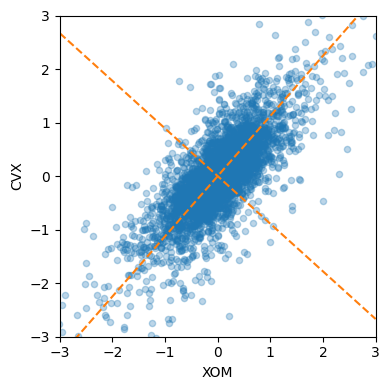

In [1]:
def abline(slope, intercept, ax):
    """Calculate coordinates of a line based on slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

ax = oil_px.plot.scatter(x="XOM", y="CVX", alpha=0.3, figsize=(4, 4))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.plot(*abline(loadings.loc[0, "CVX"] / loadings.loc[0, "XOM"], 0, ax),
        "--", color="C1")
ax.plot(*abline(loadings.loc[1, "CVX"] / loadings.loc[1, "XOM"], 0, ax),
        "--", color="C1")

plt.tight_layout()
plt.show()

#### Interpreting Principal Components

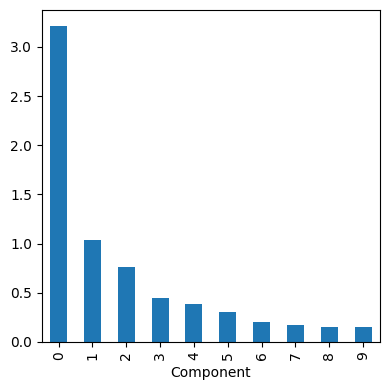

In [1]:
syms = sorted(["AAPL", "MSFT", "CSCO", "INTC", "CVX", "XOM", "SLB", "COP",
               "JPM", "WFC", "USB", "AXP", "WMT", "TGT", "HD", "COST"])
top_sp = sp500_px.loc[sp500_px.index >= "2011-01-01", syms]

sp_pca = PCA()
sp_pca.fit(top_sp)

explained_variance = pd.DataFrame(sp_pca.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel("Component")

plt.tight_layout()
plt.show()

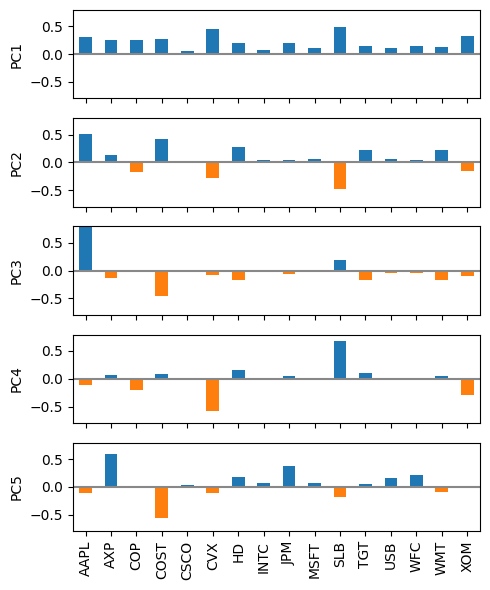

In [1]:
loadings = pd.DataFrame(sp_pca.components_[0:5, :], columns=top_sp.columns)
max_loading = 1.01 * np.max(np.max(np.abs(loadings.loc[0:5, :])))

f, axes = plt.subplots(5, 1, figsize=(5, 6), sharex=True)
for i, ax in enumerate(axes):
    pc_loadings = loadings.loc[i, :]
    colors = ["C0" if loading > 0 else "C1" for loading in pc_loadings]
    ax.axhline(color="#888888")
    pc_loadings.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f"PC{i + 1}")
    ax.set_ylim(-max_loading, max_loading)

plt.tight_layout()
plt.show()

#### Correspondence Analysis

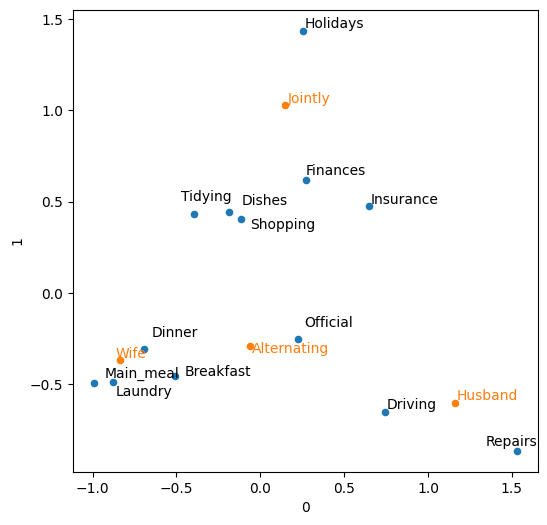

In [1]:
housetasks = pd.read_csv(DATA_DIR / "housetasks.csv", index_col=0)

ca = prince.CA(n_components=2)
ca = ca.fit(housetasks)

ax = ca.row_coordinates(housetasks).plot.scatter(x=0, y=1, figsize=(6, 6))
ca.column_coordinates(housetasks).plot.scatter(x=0, y=1, ax=ax, c="C1")
texts = []
for idx, row in ca.row_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx))
for idx, row in ca.column_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx, color="C1"))
adjust_text(texts, only_move={"points": "y", "texts": "y"})
plt.show()

### K-Means Clustering
#### A Simple Example

In [1]:
df = sp500_px.loc[sp500_px.index >= "2011-01-01", ["XOM", "CVX"]]
kmeans = KMeans(n_clusters=4).fit(df)

In [1]:
df["cluster"] = kmeans.labels_
df.head()

,XOM,CVX,cluster
Date,,,
2011-01-03,0.736805,0.240681,1
2011-01-04,0.168668,-0.584516,3
2011-01-05,0.026631,0.446985,1
2011-01-06,0.248558,-0.919751,3
2011-01-07,0.337329,0.180511,1


In [1]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=["XOM", "CVX"])
centers

,XOM,CVX
0,-1.129224,-1.729708
1,0.296863,0.392141
2,1.009182,1.489102
3,-0.308915,-0.521594


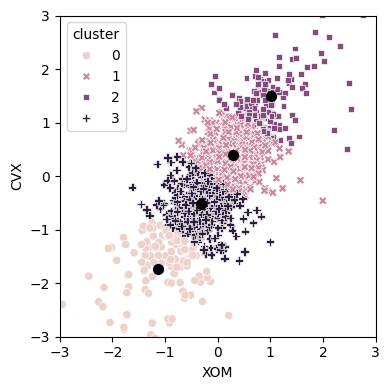

In [1]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.scatterplot(x="XOM", y="CVX", hue="cluster", style="cluster",
                     ax=ax, data=df)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
centers.plot.scatter(x="XOM", y="CVX", ax=ax, s=50, color="black")

plt.tight_layout()
plt.show()

#### K-Means Algorithm

In [1]:
syms = sorted(["AAPL", "MSFT", "CSCO", "INTC", "CVX", "XOM", "SLB", "COP",
               "JPM", "WFC", "USB", "AXP", "WMT", "TGT", "HD", "COST"])
top_sp = sp500_px.loc[sp500_px.index >= "2011-01-01", syms]
kmeans = KMeans(n_clusters=5).fit(top_sp)

#### Interpreting the Clusters

In [1]:
Counter(kmeans.labels_)

Counter({np.int32(0): 280,
         np.int32(3): 251,
         np.int32(1): 220,
         np.int32(2): 194,
         np.int32(4): 186})

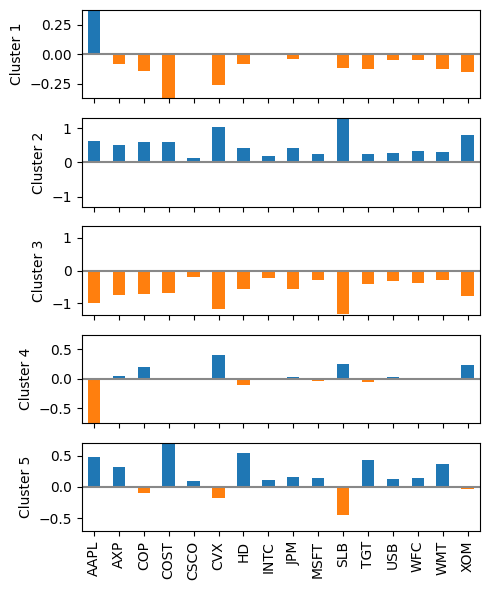

In [1]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)

f, axes = plt.subplots(5, 1, figsize=(5, 6), sharex=True)
for i, ax in enumerate(axes):
    center = centers.loc[i, :]
    max_center = 1.01 * np.max(np.max(np.abs(center)))
    colors = ["C0" if cc > 0 else "C1" for cc in center]
    ax.axhline(color="#888888")
    center.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f"Cluster {i + 1}")
    ax.set_ylim(-max_center, max_center)

plt.tight_layout()
plt.show()

#### Selecting the Number of Clusters

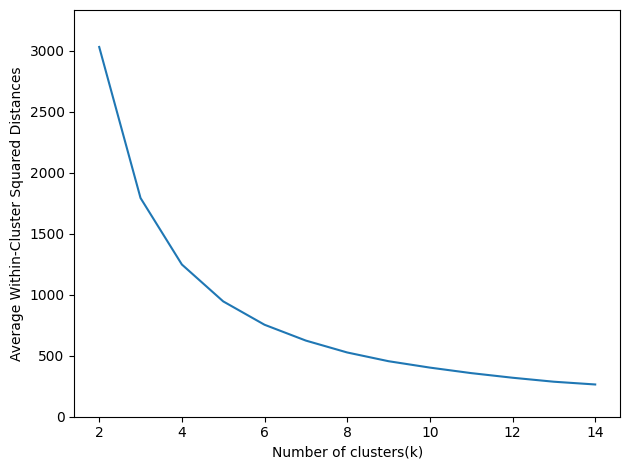

In [1]:
inertia = []
for n_clusters in range(2, 15):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(top_sp)
    inertia.append(kmeans.inertia_ / n_clusters)

inertias = pd.DataFrame({"n_clusters": range(2, 15), "inertia": inertia})
ax = inertias.plot(x="n_clusters", y="inertia")
plt.xlabel("Number of clusters(k)")
plt.ylabel("Average Within-Cluster Squared Distances")
plt.ylim((0, 1.1 * inertias.inertia.max()))
ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

### Hierarchical Clustering
#### A Simple Example

In [1]:
syms1 = ["AAPL", "AMZN", "AXP", "COP", "COST", "CSCO", "CVX", "GOOGL", "HD",
         "INTC", "JPM", "MSFT", "SLB", "TGT", "USB", "WFC", "WMT", "XOM"]
df = sp500_px.loc[sp500_px.index >= "2011-01-01", syms1].transpose()

Z = linkage(df, method="complete")

#### The Dendrogram

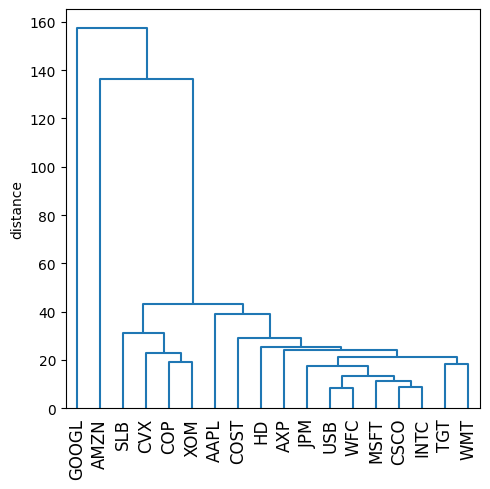

In [1]:
fig, ax = plt.subplots(figsize=(5, 5))
dendrogram(Z, labels=list(df.index), ax=ax, color_threshold=0)
plt.xticks(rotation=90)
ax.set_ylabel("distance")

plt.tight_layout()
plt.show()

In [1]:
memb = fcluster(Z, 4, criterion="maxclust")
memb = pd.Series(memb, index=df.index)
for key, item in memb.groupby(memb):
    print(f"{key} : {', '.join(item.index)}")

1 : COP, CVX, SLB, XOM
2 : AAPL, AXP, COST, CSCO, HD, INTC, JPM, MSFT, TGT, USB, WFC, WMT
3 : AMZN
4 : GOOGL


### Model-Based Clustering
#### Mixtures of Normals

In [1]:
df = sp500_px.loc[sp500_px.index >= "2011-01-01", ["XOM", "CVX"]]
mclust = GaussianMixture(n_components=2).fit(df)
mclust.bic(df)

4589.820626249873

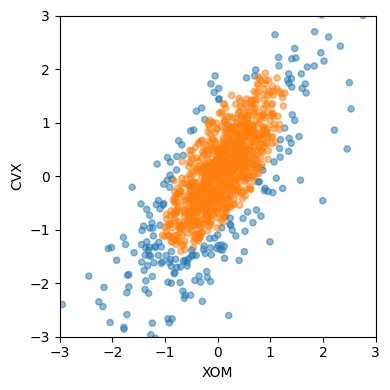

In [1]:
fig, ax = plt.subplots(figsize=(4, 4))
colors = [f"C{c}" for c in mclust.predict(df)]
df.plot.scatter(x="XOM", y="CVX", c=colors, alpha=0.5, ax=ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

In [1]:
print("Mean")
print(mclust.means_)
print("Covariances")
print(mclust.covariances_)

Mean
[[-0.05050178 -0.21237957]
 [ 0.07225117  0.10452744]]
Covariances
[[[0.97385279 0.98028909]
  [0.98028909 1.67646834]]

 [[0.26868436 0.27606914]
  [0.27606914 0.51762673]]]


#### Selecting the Number of Clusters

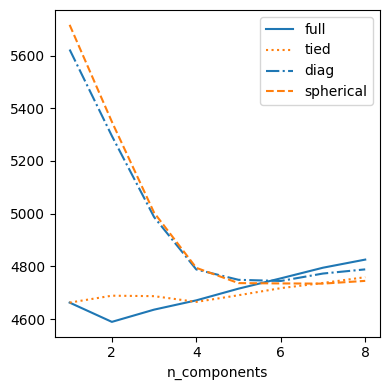

In [1]:
results = []
covariance_types = ["full", "tied", "diag", "spherical"]
for n_components in range(1, 9):
    for covariance_type in covariance_types:
        mclust = GaussianMixture(n_components=n_components, warm_start=True,
                                 covariance_type=covariance_type)
        mclust.fit(df)
        results.append({
            "bic": mclust.bic(df),
            "n_components": n_components,
            "covariance_type": covariance_type,
        })

results = pd.DataFrame(results)

colors = ["C0", "C1", "C2", "C3"]
styles = ["C0-", "C1:", "C0-.", "C1--"]

fig, ax = plt.subplots(figsize=(4, 4))
for i, covariance_type in enumerate(covariance_types):
    subset = results.loc[results.covariance_type == covariance_type, :]
    subset.plot(x="n_components", y="bic", ax=ax, label=covariance_type,
                kind="line", style=styles[i])

plt.tight_layout()
plt.show()

### Scaling and Categorical Variables
#### Scaling the Variables

In [1]:
loan_data = pd.read_csv(DATA_DIR / "loan_data.csv.gz")

defaults = loan_data.loc[loan_data["outcome"] == "default",]
columns = ["loan_amnt", "annual_inc", "revol_bal", "open_acc",
           "dti", "revol_util"]

df = defaults[columns]
kmeans = KMeans(n_clusters=4, random_state=1).fit(df)
counts = Counter(kmeans.labels_)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers["size"] = [counts[i] for i in range(4)]
centers

,loan_amnt,annual_inc,revol_bal,open_acc,dti,revol_util,size
0,17809.760881,78669.452556,18933.405997,11.594003,17.016428,62.183810,7906
1,21444.318867,148736.057263,33152.689572,12.376733,13.831145,63.151084,1654
2,24290.909091,409746.465909,84710.988636,13.431818,8.148636,60.015647,88
3,10274.160906,41241.205530,9950.095008,9.480338,17.718588,57.903425,13023


In [1]:
scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df * 1.0)

kmeans = KMeans(n_clusters=4, random_state=1).fit(df0)
counts = Counter(kmeans.labels_)

centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                       columns=columns)
centers["size"] = [counts[i] for i in range(4)]
centers

,loan_amnt,annual_inc,revol_bal,open_acc,dti,revol_util,size
0,13484.728906,55907.993263,16435.803337,14.322265,24.211535,59.463608,6244
1,25950.205142,116834.142232,32945.972921,12.396335,16.165914,66.123542,3670
2,10507.283093,51117.994063,11635.285252,7.509513,15.931561,77.795077,7397
3,10324.846369,53456.824767,6054.819926,8.664618,11.312983,30.999874,5360


#### Dominant Variables

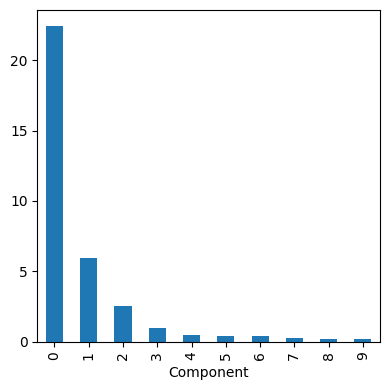

In [1]:
syms = ["GOOGL", "AMZN", "AAPL", "MSFT", "CSCO", "INTC", "CVX", "XOM",
        "SLB", "COP", "JPM", "WFC", "USB", "AXP", "WMT", "TGT", "HD", "COST"]
top_sp1 = sp500_px.loc[sp500_px.index >= "2005-01-01", syms]

sp_pca1 = PCA()
sp_pca1.fit(top_sp1)

explained_variance = pd.DataFrame(sp_pca1.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel("Component")

plt.tight_layout()
plt.show()

In [1]:
loadings = pd.DataFrame(sp_pca1.components_[0:2, :], columns=top_sp1.columns)
loadings.transpose()

,0,1
GOOGL,0.857310,-0.477873
AMZN,0.444728,0.874149
AAPL,0.071627,0.020802
MSFT,0.036002,0.006204
CSCO,0.029205,0.003045
INTC,0.026666,0.006069
CVX,0.089548,0.037420
XOM,0.080336,0.020511
SLB,0.110218,0.030356
COP,0.057739,0.024117


#### Categorical Data and Gower's Distance

In [1]:
X = defaults[["dti", "payment_inc_ratio", "home_", "purpose_"]].head(5)
gower.gower_matrix(X, cat_features=[False, False, True, True])

array([[0.        , 0.62204784, 0.68638766, 0.63290393, 0.37727892],
       [0.62204784, 0.        , 0.8143398 , 0.7608561 , 0.5389727 ],
       [0.68638766, 0.8143398 , 0.        , 0.43070832, 0.30910876],
       [0.63290393, 0.7608561 , 0.43070832, 0.        , 0.505625  ],
       [0.37727892, 0.5389727 , 0.30910876, 0.505625  , 0.        ]],
      dtype=float32)

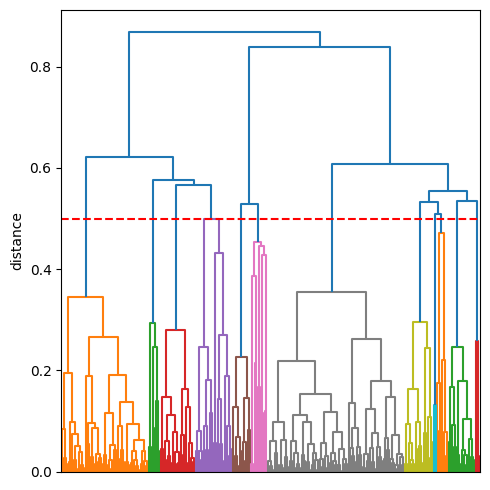

In [1]:
X = defaults[["dti", "payment_inc_ratio", "home_", "purpose_"]].sample(250,
  random_state=1)
D = gower.gower_matrix(X, cat_features=[False, False, True, True])
condensed_D = squareform(D)
Z = linkage(condensed_D, method="complete")

fig, ax = plt.subplots(figsize=(5, 5))
dendrogram(Z, labels=list(X.index), ax=ax, color_threshold=0.5)
ax.axhline(y=0.5, color="red", linestyle="--")
ax.set_xticks([])
ax.set_ylabel("distance")

plt.tight_layout()
plt.show()

In [1]:
memb = fcluster(Z, t=0.5, criterion="distance")
X[memb == 1].head(20)

,dti,payment_inc_ratio,home_,purpose_
15604,29.44,14.67510,MORTGAGE,debt_consolidation
20641,24.80,13.14330,MORTGAGE,debt_consolidation
21238,20.67,9.92934,MORTGAGE,debt_consolidation
20178,22.97,12.81220,MORTGAGE,debt_consolidation
6614,16.85,10.03790,MORTGAGE,debt_consolidation
15223,18.15,20.56450,MORTGAGE,debt_consolidation
12593,17.09,13.00490,MORTGAGE,debt_consolidation
14883,18.69,9.88416,MORTGAGE,debt_consolidation
4828,12.57,3.62216,MORTGAGE,debt_consolidation
22541,27.24,6.81531,MORTGAGE,debt_consolidation


#### Problems with Clustering Mixed Data

In [1]:
columns = ["dti", "payment_inc_ratio", "home_", "pub_rec_zero"]
df = pd.get_dummies(defaults[columns])

scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1).fit(df0)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                       columns=df.columns)
centers

,dti,payment_inc_ratio,pub_rec_zero,home__MORTGAGE,home__OWN,home__RENT
0,21.431365,12.354001,0.943315,-1.942890e-15,4.718448e-16,1.000000e+00
1,12.743276,5.918701,0.900372,-1.276756e-15,1.526557e-16,1.000000e+00
2,17.339786,8.353535,0.905716,1.000000e+00,-5.134781e-16,-4.163336e-15
3,17.197993,9.266666,0.917903,1.054712e-15,1.000000e+00,-2.775558e-16


# Supplementary Material
## Figure 7-4. Graphical representation of a correspondence analysis of house task data

## Figure 7-5. The clusters of K-means applied to daily stock returns for ExxonMobil and Chevron

## Figure 7-9. A comparison of measures of dissimilarity applied to stock data

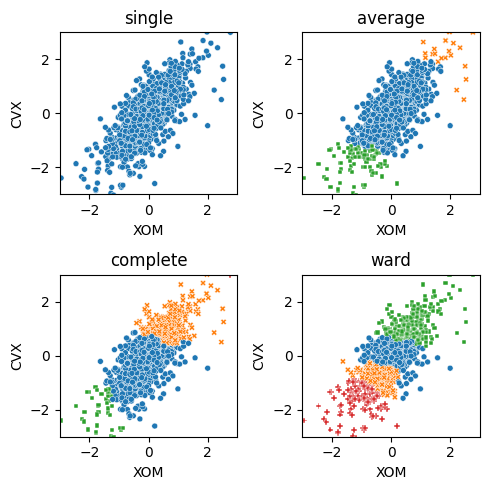

In [1]:
df = sp500_px.loc[sp500_px.index >= "2011-01-01", ["XOM", "CVX"]]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
for i, method in enumerate(["single", "average", "complete", "ward"]):
    ax = axes[i // 2, i % 2]
    Z = linkage(df, method=method)
    colors = [f"C{c + 1}" for c in fcluster(Z, 4, criterion="maxclust")]
    ax = sns.scatterplot(x="XOM", y="CVX", hue=colors, style=colors,
                         size=0.5, ax=ax, data=df, legend=False)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(method)


plt.tight_layout()
plt.show()

## Figure 7-10. Probability contours for a two-dimensional normal distribution

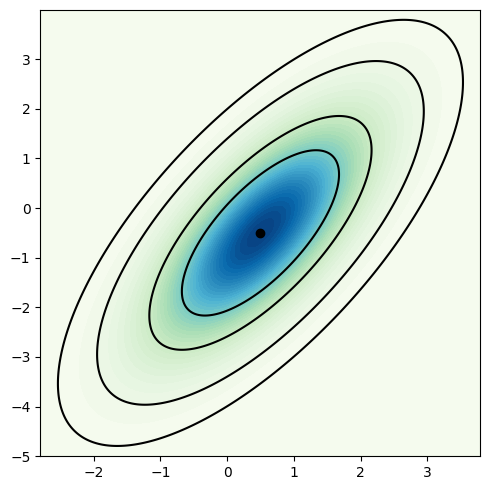

In [1]:
mean = [0.5, -0.5]
cov = [[1, 1], [1, 2]]
probability = [0.5, 0.75, 0.95, 0.99]
def prob_level(p):
    return (1 - p) / (2 * math.pi)
levels = [prob_level(p) for p in probability]

fig, ax = plt.subplots(figsize=(5, 5))

x, y = np.mgrid[-2.8:3.8:.01, -5:4:.01]
pos = np.empty((*x.shape, 2))
pos[:, :, 0] = x; pos[:, :, 1] = y
rv = multivariate_normal(mean, cov)


CS = ax.contourf(x, y, rv.pdf(pos), cmap=cm.GnBu, levels=50)
ax.contour(CS, levels=levels, colors=["black"])
ax.plot(*mean, color="black", marker="o")


plt.tight_layout()
plt.show()